[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab3-GenAI-LLM/notebooks/04-prompt-engineering.ipynb)

# Prompt Engineering for Healthcare Tasks

**ELMED219 / BMED365 - Lab 3**

Last updated:<br>
2026-01-03, A. Lundervold

---

## Learning Objectives

After this notebook, you should be able to:
- Understand the difference between *prompt engineering* and *context engineering*
- Master basic prompt techniques
- Apply zero-shot and few-shot learning
- Implement chain-of-thought for complex assessments
- Design safe prompts for medical tasks
- Compose rich context for clinical AI applications

## Contents

1. [Basic Principles](#1-basic-principles)
2. [Zero-shot vs. Few-shot](#2-zero-shot-vs-few-shot)
3. [Chain-of-Thought (CoT)](#3-chain-of-thought-cot)
4. [Structured Output](#4-structured-output)
5. [Safety in Medical Prompts](#5-safety-in-medical-prompts)
6. [Practical Examples](#6-practical-examples)
7. [GPT-5.2 Prompting Guide for Medicine](#7-gpt-52-prompting-guide-for-medicine)
8. [Claude Opus 4.5 Prompting Guide for Medicine](#8-claude-opus-45-prompting-guide-for-medicine)
9. [Gemini 3 Prompting Guide for Medicine](#9-gemini-3-prompting-guide-for-medicine)

---

## 1. Basic Principles

Good prompt engineering is about communicating clearly with the AI model. Think of it as giving instructions to a very knowledgeable, but literal assistant.

### From Prompt Engineering to Context Engineering

While **prompt engineering** focuses on crafting good questions and instructions, **context engineering** encompasses the entire picture of information that the model has access to. Context engineering is the art of designing and managing the *entire context window* that an LLM uses to generate responses.

#### What is Context Engineering?

Context engineering is about strategically composing all the elements that influence the model's response:

| Component | Description | Medical Example |
|-----------|-------------|-----------------|
| **System prompt** | Basic instructions and role | "You are a clinical decision support assistant" |
| **User prompt** | The specific question | "Assess this patient's symptoms" |
| **Tools/functions** | Available actions | Laboratory search, drug database, ICD-10 lookup |
| **Retrieved context (RAG)** | Dynamically retrieved information | Patient records, guidelines, scientific articles |
| **Conversation history** | Previous dialogue | Previous questions and answers in the consultation |
| **Structured data** | Formatted information | JSON with lab values, vital signs |

#### Why is Context Engineering Important in Medicine?

In medical applications, context is *critical* because:

1. **Patient Safety**: Correct context can prevent dangerous recommendations
2. **Personalization**: Patient-specific information provides relevant answers
3. **Evidence-based**: Access to updated guidelines ensures quality
4. **Traceability**: Structured context enables review and quality control
5. **Regulatory compliance**: Documented context sources support medical software requirements

#### How to Develop Skills in Context Engineering?

| Skill Level | Focus Area | Practical Exercise |
|-------------|-----------|-------------------|
| **Beginner** | Prompt formulation | Experiment with role, format, and examples |
| **Intermediate** | Context organization | Design structured system prompts with sections |
| **Advanced** | RAG and tools | Integrate external knowledge sources and APIs |
| **Expert** | Orchestration | Build multi-agent systems with specialized roles |

> 💡 **Tip**: Start by thinking "What information would an experienced clinician need to answer this question?" – this is the core of good context engineering.

### The Four Basic Principles of Prompts

| Principle | Description | Example |
|-----------|-------------|---------|
| **Specificity** | Be concrete about what you want | "Write 3 points" vs. "Write a bit" |
| **Context** | Provide relevant background information | "You are a general practitioner who..." |
| **Format** | Specify the desired output format | "Answer in JSON format" |
| **Examples** | Show what you expect | Few-shot learning |

In [22]:
# Illustration: Prompt Engineering vs. Context Engineering

# PROMPT ENGINEERING: Focus on the question itself
simple_prompt = "What is the treatment for heart failure?"

# CONTEXT ENGINEERING: The entire context window
context_components = {
    "system_prompt": """You are a clinical decision support assistant at a Norwegian hospital.
    
IMPORTANT GUIDELINES:
- Follow ESC Guidelines for Heart Failure 2023
- Always refer to specialist in case of uncertainty
- Never give specific dosing recommendations without pharmaceutical review
- Always document knowledge base with references""",
    
    "patient_context": {
        "age": 72,
        "gender": "male",
        "diagnoses": ["Heart Failure NYHA III", "Atrial Fibrillation", "Diabetes type 2"],
        "eGFR": 45,  # Renal function - important for medication selection
        "current_medications": ["Metformin 500mg x2", "Warfarin"],
        "allergies": ["Penicillin"]
    },
    
    "retrieved_context_RAG": [
        "ESC Guidelines 2023: SGLT2 inhibitors recommended regardless of EF...",
        "Interaction database: Warfarin + NSAID = increased bleeding risk..."
    ],
    
    "user_prompt": "What treatment changes should be considered for this patient?"
}

print("=" * 70)
print("SIMPLE PROMPT (Prompt Engineering):")
print("=" * 70)
print(simple_prompt)
print(f"\nContext available to the model: {len(simple_prompt)} characters")

print("\n" + "=" * 70)
print("RICH CONTEXT (Context Engineering):")
print("=" * 70)
import json
print(json.dumps(context_components, indent=2, ensure_ascii=False))

total_context = len(json.dumps(context_components))
print(f"\nContext available to the model: {total_context} characters")
print(f"Improvement: {total_context / len(simple_prompt):.0f}x more context")

SIMPLE PROMPT (Prompt Engineering):
What is the treatment for heart failure?

Context available to the model: 40 characters

RICH CONTEXT (Context Engineering):
{
  "system_prompt": "You are a clinical decision support assistant at a Norwegian hospital.\n    \nIMPORTANT GUIDELINES:\n- Follow ESC Guidelines for Heart Failure 2023\n- Always refer to specialist in case of uncertainty\n- Never give specific dosing recommendations without pharmaceutical review\n- Always document knowledge base with references",
  "patient_context": {
    "age": 72,
    "gender": "male",
    "diagnoses": [
      "Heart Failure NYHA III",
      "Atrial Fibrillation",
      "Diabetes type 2"
    ],
    "eGFR": 45,
    "current_medications": [
      "Metformin 500mg x2",
      "Warfarin"
    ],
    "allergies": [
      "Penicillin"
    ]
  },
  "retrieved_context_RAG": [
    "ESC Guidelines 2023: SGLT2 inhibitors recommended regardless of EF...",
    "Interaction database: Warfarin + NSAID = increased bleeding 

### Example: Bad vs. Good Prompt

**Bad prompt:**
```
Tell me about diabetes
```

**Good prompt:**
```
You are an experienced general practitioner who explains diagnoses to patients.

Explain type 2 diabetes to a newly diagnosed 55-year-old patient.

Include:
1. What happens in the body (2-3 sentences, simple language)
2. Common symptoms (bullet list, max 5)
3. Why treatment is important (2 sentences)
4. Three concrete lifestyle advice they can start with today

Use a friendly, reassuring tone. Avoid medical jargon.
Maximum 150 words total.
```

In [23]:
# Let's analyze the differences

bad_prompt = "Tell me about diabetes"

good_prompt = """You are an experienced general practitioner who explains diagnoses to patients.

Explain type 2 diabetes to a newly diagnosed 55-year-old patient.

Include:
1. What happens in the body (2-3 sentences, simple language)
2. Common symptoms (bullet list, max 5)
3. Why treatment is important (2 sentences)
4. Three concrete lifestyle advice they can start with today

Use a friendly, reassuring tone. Avoid medical jargon.
Maximum 150 words total."""

print("BAD PROMPT:")
print(f"  Length: {len(bad_prompt)} characters")
print(f"  Missing: Role, target audience, format, limitations")
print()
print("GOOD PROMPT:")
print(f"  Length: {len(good_prompt)} characters")
print(f"  Contains:")
print(f"    - Role: 'experienced general practitioner'")
print(f"    - Target audience: 'newly diagnosed 55-year-old patient'")
print(f"    - Structure: 4 specific points")
print(f"    - Tone: 'friendly, reassuring'")
print(f"    - Limitation: 'Maximum 150 words'")

BAD PROMPT:
  Length: 22 characters
  Missing: Role, target audience, format, limitations

GOOD PROMPT:
  Length: 443 characters
  Contains:
    - Role: 'experienced general practitioner'
    - Target audience: 'newly diagnosed 55-year-old patient'
    - Structure: 4 specific points
    - Tone: 'friendly, reassuring'
    - Limitation: 'Maximum 150 words'


---

## 2. Zero-shot vs. Few-shot

### Zero-shot
The model solves the task without examples - only based on instructions.

### Few-shot
We give the model some examples of the desired input-output before the actual task.

### When to Use What?

| Situation | Recommended Technique |
|-----------|----------------------|
| Simple, known task | Zero-shot |
| Specific format/style | Few-shot |
| Domain-specific terminology | Few-shot |
| Classification with ground truth | Few-shot |

In [24]:
# Example: Triage Classification

# ZERO-SHOT: No examples
zero_shot_prompt = """Classify the following symptom description as either 'ACUTE' or 'NON-ACUTE':

"The patient reports chest pain radiating to the left arm, 
shortness of breath and nausea in the last 30 minutes."

Answer only with the classification."""

print("ZERO-SHOT PROMPT:")
print("-" * 50)
print(zero_shot_prompt)
print()

# FEW-SHOT: With examples
few_shot_prompt = """Classify symptom descriptions as 'ACUTE' or 'NON-ACUTE'.

Examples:

Symptoms: "Headache for 3 days, gradually worsening"
Classification: NON-ACUTE

Symptoms: "Sudden severe headache, stiff neck, fever"
Classification: ACUTE

Symptoms: "Mild cold with runny nose"
Classification: NON-ACUTE

Symptoms: "Sudden vision loss in one eye 15 minutes ago"
Classification: ACUTE

Now classify:
Symptoms: "The patient reports chest pain radiating to the left arm, 
shortness of breath and nausea in the last 30 minutes."
Classification:"""

print("FEW-SHOT PROMPT:")
print("-" * 50)
print(few_shot_prompt)

ZERO-SHOT PROMPT:
--------------------------------------------------
Classify the following symptom description as either 'ACUTE' or 'NON-ACUTE':

"The patient reports chest pain radiating to the left arm, 
shortness of breath and nausea in the last 30 minutes."

Answer only with the classification.

FEW-SHOT PROMPT:
--------------------------------------------------
Classify symptom descriptions as 'ACUTE' or 'NON-ACUTE'.

Examples:

Symptoms: "Headache for 3 days, gradually worsening"
Classification: NON-ACUTE

Symptoms: "Sudden severe headache, stiff neck, fever"
Classification: ACUTE

Symptoms: "Mild cold with runny nose"
Classification: NON-ACUTE

Symptoms: "Sudden vision loss in one eye 15 minutes ago"
Classification: ACUTE

Now classify:
Symptoms: "The patient reports chest pain radiating to the left arm, 
shortness of breath and nausea in the last 30 minutes."
Classification:


### Advantages of Few-shot

1. **Consistency**: The model follows the pattern from the examples
2. **Accuracy**: Reduces misunderstandings
3. **Format**: Ensures correct output format
4. **Domain adaptation**: Shows desired terminology and style

---

## 3. Chain-of-Thought (CoT)

Chain-of-Thought asks the model to show its thought process step by step. This is particularly useful for:

- Complex reasoning
- Diagnostic assessments
- Mathematical calculations
- Decisions with multiple factors

### Why Does It Work?

When the model "thinks aloud", it must structure the reasoning logically, which often leads to better answers.

In [25]:
# Example: Differential Diagnosis with and without CoT

case = """65-year-old man with type 2 diabetes and hypertension.
Presents with acute chest pain, sweating and nausea.
BP 160/100, pulse 95, temperature normal."""

# WITHOUT Chain-of-Thought
simple_prompt = f"""Case: {case}

Question: Should the patient be admitted?
Answer briefly."""

print("WITHOUT Chain-of-Thought:")
print("=" * 50)
print(simple_prompt)
print()

# WITH Chain-of-Thought
cot_prompt = f"""Case: {case}

Assess this case step-by-step:

STEP 1: Identify risk factors
- List the patient's risk factors for heart disease

STEP 2: Assess symptom severity
- Are the symptoms typical for a specific condition?
- What are the differential diagnoses?

STEP 3: Assess vital signs
- Are blood pressure and pulse concerning?

STEP 4: Conclusion
- Based on steps 1-3, should the patient be admitted?
- Justify your answer.

Show your thought process for each step."""

print("WITH Chain-of-Thought:")
print("=" * 50)
print(cot_prompt)

WITHOUT Chain-of-Thought:
Case: 65-year-old man with type 2 diabetes and hypertension.
Presents with acute chest pain, sweating and nausea.
BP 160/100, pulse 95, temperature normal.

Question: Should the patient be admitted?
Answer briefly.

WITH Chain-of-Thought:
Case: 65-year-old man with type 2 diabetes and hypertension.
Presents with acute chest pain, sweating and nausea.
BP 160/100, pulse 95, temperature normal.

Assess this case step-by-step:

STEP 1: Identify risk factors
- List the patient's risk factors for heart disease

STEP 2: Assess symptom severity
- Are the symptoms typical for a specific condition?
- What are the differential diagnoses?

STEP 3: Assess vital signs
- Are blood pressure and pulse concerning?

STEP 4: Conclusion
- Based on steps 1-3, should the patient be admitted?
- Justify your answer.

Show your thought process for each step.


### Tips for Effective CoT

1. **Explicit steps**: Number the steps clearly
2. **Specific questions**: Ask concrete questions for each step
3. **Logical order**: Build toward the conclusion
4. **Ask for justification**: "Explain why" is powerful

---

## 4. Structured Output

For programmatic use, it is useful to request structured output such as JSON.

In [26]:
# Example: Structured Medical Record Note

structured_prompt = """Analyze the following consultation notes and generate a structured summary.

CONSULTATION:
Patient 45 years old, female. Presents due to fatigue for the last 2 months.
Sleeps poorly, wakes several times. Stressed at work.
Eats little breakfast, lots of coffee. No exercise.
Previously healthy. Takes no medications.
Examination: BP 125/80, pulse 78. Unremarkable.
Blood tests: Hb 11.2, ferritin 18 (low-normal).
Assessing iron deficiency and sleep problems as main causes.

Generate a SOAP note in the following JSON format:

{
  "subjective": {
    "chief_complaint": "...",
    "duration": "...",
    "associated_symptoms": ["..."],
    "lifestyle": "..."
  },
  "objective": {
    "vitals": "...",
    "examination": "...",
    "laboratory": "..."
  },
  "assessment": {
    "primary_diagnosis": "...",
    "differential_diagnoses": ["..."]
  },
  "plan": [
    "..."
  ]
}"""

print(structured_prompt)

Analyze the following consultation notes and generate a structured summary.

CONSULTATION:
Patient 45 years old, female. Presents due to fatigue for the last 2 months.
Sleeps poorly, wakes several times. Stressed at work.
Eats little breakfast, lots of coffee. No exercise.
Previously healthy. Takes no medications.
Examination: BP 125/80, pulse 78. Unremarkable.
Blood tests: Hb 11.2, ferritin 18 (low-normal).
Assessing iron deficiency and sleep problems as main causes.

Generate a SOAP note in the following JSON format:

{
  "subjective": {
    "chief_complaint": "...",
    "duration": "...",
    "associated_symptoms": ["..."],
    "lifestyle": "..."
  },
  "objective": {
    "vitals": "...",
    "examination": "...",
    "laboratory": "..."
  },
  "assessment": {
    "primary_diagnosis": "...",
    "differential_diagnoses": ["..."]
  },
  "plan": [
    "..."
  ]
}


In [27]:
# Simulated response for demonstration
import json

simulated_response = {
    "subjective": {
        "chief_complaint": "Fatigue",
        "duration": "2 months",
        "associated_symptoms": ["Sleep difficulties", "Frequent awakening"],
        "lifestyle": "High stress level, irregular meals, lots of caffeine, no exercise"
    },
    "objective": {
        "vitals": "BP 125/80, pulse 78",
        "examination": "Unremarkable",
        "laboratory": "Hb 11.2 g/dL, Ferritin 18 ng/mL (low-normal)"
    },
    "assessment": {
        "primary_diagnosis": "Iron deficiency with incipient anemia",
        "differential_diagnoses": ["Sleep disorder", "Stress-related exhaustion", "Hypothyroidism"]
    },
    "plan": [
        "Iron supplement 100mg daily",
        "Sleep hygiene advice",
        "Check TSH to rule out thyroid disease",
        "Follow-up in 6-8 weeks with new blood tests"
    ]
}

print("STRUCTURED OUTPUT (JSON):")
print("=" * 50)
print(json.dumps(simulated_response, indent=2, ensure_ascii=False))

STRUCTURED OUTPUT (JSON):
{
  "subjective": {
    "chief_complaint": "Fatigue",
    "duration": "2 months",
    "associated_symptoms": [
      "Sleep difficulties",
      "Frequent awakening"
    ],
    "lifestyle": "High stress level, irregular meals, lots of caffeine, no exercise"
  },
  "objective": {
    "vitals": "BP 125/80, pulse 78",
    "examination": "Unremarkable",
    "laboratory": "Hb 11.2 g/dL, Ferritin 18 ng/mL (low-normal)"
  },
  "assessment": {
    "primary_diagnosis": "Iron deficiency with incipient anemia",
    "differential_diagnoses": [
      "Sleep disorder",
      "Stress-related exhaustion",
      "Hypothyroidism"
    ]
  },
  "plan": [
    "Iron supplement 100mg daily",
    "Sleep hygiene advice",
    "Check TSH to rule out thyroid disease",
    "Follow-up in 6-8 weeks with new blood tests"
  ]
}


---

## 5. Safety in Medical Prompts

When we use LLMs for medical tasks, we must include safety instructions.

### Important Elements

1. **Disclaimer**: AI does not replace clinical judgment
2. **Referral**: Always recommend contacting healthcare personnel
3. **Limitations**: Be clear about what AI cannot/should not do
4. **Uncertainty**: Ask the model to express uncertainty when relevant

In [28]:
# Template for safe medical prompt

safe_prompt_template = """ROLE:
You are a medical information assistant who provides general health information.

IMPORTANT LIMITATIONS:
1. You do NOT give medical diagnoses or treatment recommendations
2. You do NOT replace consultation with qualified healthcare personnel
3. For acute symptoms: Always recommend contacting a doctor/emergency services
4. Be clear about uncertainty and limitations in your knowledge
5. Never give specific medication dosages

TASK:
[Your task here]

FORMAT:
Start the answer with: "This information is for guidance only and does not replace medical advice."
End with: "Contact a doctor for personal assessment."
"""

print("TEMPLATE FOR SAFE MEDICAL PROMPT:")
print("=" * 50)
print(safe_prompt_template)

TEMPLATE FOR SAFE MEDICAL PROMPT:
ROLE:
You are a medical information assistant who provides general health information.

IMPORTANT LIMITATIONS:
1. You do NOT give medical diagnoses or treatment recommendations
2. You do NOT replace consultation with qualified healthcare personnel
3. For acute symptoms: Always recommend contacting a doctor/emergency services
4. Be clear about uncertainty and limitations in your knowledge
5. Never give specific medication dosages

TASK:
[Your task here]

FORMAT:
Start the answer with: "This information is for guidance only and does not replace medical advice."
End with: "Contact a doctor for personal assessment."



In [29]:
# Example: Safe Handling of Symptom Questions

uncertain_question = "How much Paracetamol can I take for severe pain?"

safe_prompt = f"""ROLE:
You are a medical information assistant.

IMPORTANT LIMITATIONS:
1. Never give specific dosing recommendations
2. Always refer to package insert or pharmacy
3. In case of uncertainty, recommend contacting a doctor

USER QUESTION:
{uncertain_question}

ANSWER RESPONSIBLY:"""

print("QUESTION:", uncertain_question)
print()
print("SAFE PROMPT:")
print("-" * 50)
print(safe_prompt)
print()
print("EXPECTED TYPE OF ANSWER:")
print("-" * 50)
print("""I cannot give specific dosing recommendations as this depends on 
several factors such as your age, weight, other medications and health status.

Generally I recommend:
1. Read the package insert carefully
2. Ask at the pharmacy for guidance
3. For severe or persistent pain, contact a doctor

In case of overdose or side effects, contact the Poison Information Center (22 59 13 00).""")

QUESTION: How much Paracetamol can I take for severe pain?

SAFE PROMPT:
--------------------------------------------------
ROLE:
You are a medical information assistant.

IMPORTANT LIMITATIONS:
1. Never give specific dosing recommendations
2. Always refer to package insert or pharmacy
3. In case of uncertainty, recommend contacting a doctor

USER QUESTION:
How much Paracetamol can I take for severe pain?

ANSWER RESPONSIBLY:

EXPECTED TYPE OF ANSWER:
--------------------------------------------------
I cannot give specific dosing recommendations as this depends on 
several factors such as your age, weight, other medications and health status.

Generally I recommend:
1. Read the package insert carefully
2. Ask at the pharmacy for guidance
3. For severe or persistent pain, contact a doctor

In case of overdose or side effects, contact the Poison Information Center (22 59 13 00).


---

## 6. Practical Examples

Here are some ready-made prompts for common medical tasks.

In [30]:
# EXAMPLE 1: Medical Record Summary

medical_record_summary_prompt = """TASK: Create a brief summary of the following patient record.

RECORD:
15.01.2024: Diabetes check. HbA1c 7.2%, weight 89 kg. Continue metformin.
03.02.2024: Phone call - question about new medication. Explained side effects.
20.02.2024: Acute appointment - UTI. Dysuria, pollakiuria. Urine dipstick positive. Pivmecillinam 5 days.
15.03.2024: Diabetes check. HbA1c 6.9%, down 0.3%. Weight 87 kg. Very satisfied.

FORMAT:
Write a summary in max 3 sentences covering:
- Primary diagnosis and progression
- Most important events
- Current status"""

print("EXAMPLE 1: Medical Record Summary")
print("=" * 50)
print(medical_record_summary_prompt)

EXAMPLE 1: Medical Record Summary
TASK: Create a brief summary of the following patient record.

RECORD:
15.01.2024: Diabetes check. HbA1c 7.2%, weight 89 kg. Continue metformin.
03.02.2024: Phone call - question about new medication. Explained side effects.
20.02.2024: Acute appointment - UTI. Dysuria, pollakiuria. Urine dipstick positive. Pivmecillinam 5 days.
15.03.2024: Diabetes check. HbA1c 6.9%, down 0.3%. Weight 87 kg. Very satisfied.

FORMAT:
Write a summary in max 3 sentences covering:
- Primary diagnosis and progression
- Most important events
- Current status


In [31]:
# EXAMPLE 2: Patient-Friendly Explanation

patient_explanation_prompt = """ROLE: You are a general practitioner who explains medical conditions to patients.

TASK: Explain the following condition in an understandable way.

CONDITION: Atrial Fibrillation
PATIENT: 68 years old, female, worried

REQUIREMENTS:
1. Use simple language - avoid medical jargon
2. Explain what happens in the heart (use an analogy if possible)
3. Mention common symptoms
4. Explain why treatment is important
5. Be reassuring but honest
6. Maximum 100 words

EXAMPLE OF GOOD ANALOGY:
"Think of the heart as a conductor keeping the beat. With atrial fibrillation 
the conductor loses the rhythm a bit, so the orchestra plays a bit unevenly."""

print("EXAMPLE 2: Patient-Friendly Explanation")
print("=" * 50)
print(patient_explanation_prompt)

EXAMPLE 2: Patient-Friendly Explanation
ROLE: You are a general practitioner who explains medical conditions to patients.

TASK: Explain the following condition in an understandable way.

CONDITION: Atrial Fibrillation
PATIENT: 68 years old, female, worried

REQUIREMENTS:
1. Use simple language - avoid medical jargon
2. Explain what happens in the heart (use an analogy if possible)
3. Mention common symptoms
4. Explain why treatment is important
5. Be reassuring but honest
6. Maximum 100 words

EXAMPLE OF GOOD ANALOGY:
"Think of the heart as a conductor keeping the beat. With atrial fibrillation 
the conductor loses the rhythm a bit, so the orchestra plays a bit unevenly.


In [32]:
# EXAMPLE 3: Triage Assessment

triage_prompt = """TASK: Assess urgency level for the following symptom description.

USE THE FOLLOWING CATEGORIES:
- RED: Life-threatening, requires immediate help (call emergency services)
- ORANGE: Urgent, should be assessed by doctor within hours
- YELLOW: Should be assessed by doctor within 1-2 days  
- GREEN: Can wait, suitable for general practitioner/self-care

SYMPTOM DESCRIPTION:
[Insert symptoms here]

ANSWER FORMAT:
1. Urgency level: [RED/ORANGE/YELLOW/GREEN]
2. Justification: [2-3 sentences]
3. Recommended action: [Concrete advice]
4. Red flags to watch for: [List]

IMPORTANT: This is for guidance only. In case of uncertainty, choose higher urgency level."""

print("EXAMPLE 3: Triage Assessment")
print("=" * 50)
print(triage_prompt)

EXAMPLE 3: Triage Assessment
TASK: Assess urgency level for the following symptom description.

USE THE FOLLOWING CATEGORIES:
- RED: Life-threatening, requires immediate help (call emergency services)
- ORANGE: Urgent, should be assessed by doctor within hours
- YELLOW: Should be assessed by doctor within 1-2 days  
- GREEN: Can wait, suitable for general practitioner/self-care

SYMPTOM DESCRIPTION:
[Insert symptoms here]

ANSWER FORMAT:
1. Urgency level: [RED/ORANGE/YELLOW/GREEN]
2. Justification: [2-3 sentences]
3. Recommended action: [Concrete advice]
4. Red flags to watch for: [List]

IMPORTANT: This is for guidance only. In case of uncertainty, choose higher urgency level.


---

## 7. GPT-5.2 Prompting Guide for Medicine

OpenAI launched in December 2024 a [GPT-5.2 Prompting Guide](https://cookbook.openai.com/examples/gpt-5/gpt-5-2_prompting_guide) containing best practices for effective use of their latest model. Here we translate and adapt the most relevant parts for medical tasks.

### 7.1 Introduction to GPT-5.2

GPT-5.2 is OpenAI's flagship model for enterprise and agentic workflows, designed for:
- **Higher accuracy** and stronger instruction following
- **Disciplined execution** across complex workflows
- **Token efficiency** on medium to complex tasks
- **Cleaner formatting** with less unnecessary verbosity

For medical applications, GPT-5.2 is particularly useful because of:
- Stronger structured reasoning
- Better tool grounding
- Improved multimodal understanding (e.g., interpretation of medical images and documents)

### 7.2 Handling Ambiguity and Hallucination Risk

In medical contexts, it is critical to handle uncertainty in a responsible way. The GPT-5.2 guide recommends the following prompt pattern:

```
<uncertainty_and_ambiguity>
- If the question is ambiguous or underspecified, point this out explicitly and:
  - Ask up to 1–3 precise clarifying questions, OR
  - Present 2–3 plausible interpretations with clearly marked assumptions.
- When external facts may have changed recently (guidelines, medications, procedures) and no tools are available:
  - Answer in general terms and state that details may have changed.
- Never fabricate exact numbers, line numbers, or external references when uncertain.
- When uncertain, prefer formulations like "Based on given context..." instead of absolute statements.
</uncertainty_and_ambiguity>
```

For high-risk tasks (such as medicine), a self-check is also recommended:

In [33]:
# Medical prompt with GPT-5.2 anti-hallucination pattern

medical_uncertainty_prompt = """<high_risk_self_check>
Before finalizing an answer in medical, legal, compliance, or security-sensitive contexts:
- Quickly scan through your own answer for:
  - Unstated assumptions
  - Specific numbers or claims not grounded in context
  - Too strong language ("always", "guaranteed", "certain")
- If you find anything, soften or qualify it and state the assumptions explicitly.
</high_risk_self_check>

<uncertainty_and_ambiguity>
- For ambiguous symptoms or diagnoses, present differential diagnoses with probability
- Clearly state knowledge limitations and update date
- Always refer to current guidelines and clinical judgment
- In case of uncertainty: Escalate to higher urgency level rather than underestimating
</uncertainty_and_ambiguity>"""

print("MEDICAL UNCERTAINTY PROMPT (GPT-5.2 PATTERN):")
print("=" * 60)
print(medical_uncertainty_prompt)

MEDICAL UNCERTAINTY PROMPT (GPT-5.2 PATTERN):
<high_risk_self_check>
Before finalizing an answer in medical, legal, compliance, or security-sensitive contexts:
- Quickly scan through your own answer for:
  - Unstated assumptions
  - Specific numbers or claims not grounded in context
  - Too strong language ("always", "guaranteed", "certain")
- If you find anything, soften or qualify it and state the assumptions explicitly.
</high_risk_self_check>

<uncertainty_and_ambiguity>
- For ambiguous symptoms or diagnoses, present differential diagnoses with probability
- Clearly state knowledge limitations and update date
- Always refer to current guidelines and clinical judgment
- In case of uncertainty: Escalate to higher urgency level rather than underestimating
</uncertainty_and_ambiguity>


### 7.3 Structured Extraction from Medical Documents

GPT-5.2 shows particularly strong improvements for structured extraction from PDFs and Office documents. This is highly relevant for medical workflows such as:
- Extraction from discharge summaries and medical record notes
- Parsing of laboratory results
- Analysis of medical research articles
- Processing of prescriptions and medication lists

**Best practices:**
1. **Always provide a schema** or JSON structure for output
2. **Distinguish between required and optional fields**
3. **Ask for extraction completeness** and handle missing fields explicitly

In [34]:
# GPT-5.2 pattern for structured extraction from medical document

extraction_prompt = """<extraction_specification>
You shall extract structured data from discharge summaries/medical record notes to JSON.

- Always follow this schema exactly (no extra fields):
  {
    "patient_info": {
      "age": int | null,
      "gender": "male" | "female" | "other" | null,
      "primary_diagnosis_icd10": string | null,
      "secondary_diagnoses_icd10": [string] | null
    },
    "admission": {
      "date": "YYYY-MM-DD" | null,
      "department": string | null,
      "admission_reason": string | null
    },
    "treatment": {
      "procedures": [string] | null,
      "medications_at_discharge": [
        {
          "name": string,
          "dose": string,
          "frequency": string
        }
      ] | null
    },
    "follow_up": {
      "control_date": "YYYY-MM-DD" | null,
      "recommendations": [string] | null
    }
  }

- If a field does not exist in the source, set it to null instead of guessing.
- Before returning, quickly scan the source again for any omitted fields and correct.
</extraction_specification>"""

print("EXTRACTION PROMPT FOR MEDICAL DOCUMENTS:")
print("=" * 60)
print(extraction_prompt)

EXTRACTION PROMPT FOR MEDICAL DOCUMENTS:
<extraction_specification>
You shall extract structured data from discharge summaries/medical record notes to JSON.

- Always follow this schema exactly (no extra fields):
  {
    "patient_info": {
      "age": int | null,
      "gender": "male" | "female" | "other" | null,
      "primary_diagnosis_icd10": string | null,
      "secondary_diagnoses_icd10": [string] | null
    },
    "admission": {
      "date": "YYYY-MM-DD" | null,
      "department": string | null,
      "admission_reason": string | null
    },
    "treatment": {
      "procedures": [string] | null,
      "medications_at_discharge": [
        {
          "name": string,
          "dose": string,
          "frequency": string
        }
      ] | null
    },
    "follow_up": {
      "control_date": "YYYY-MM-DD" | null,
      "recommendations": [string] | null
    }
  }

- If a field does not exist in the source, set it to null instead of guessing.
- Before returning, quickly scan 

### 7.4 Web Search and Medical Research

GPT-5.2 is more controllable and capable of synthesizing information from many sources. For medical research tasks, the following is recommended:

**Best practices:**
1. **Specify research level in advance**: How deep should the model search?
2. **Limit ambiguity through instructions, not questions**: Ask the model to cover all plausible interpretations
3. **Dictate output form and tone**: Markdown, headings, tables for comparisons

**Medical research pattern:**
- Prioritize evidence-based sources (PubMed, Cochrane, UpToDate)
- Always include publication date and evidence level
- Resolve conflicting findings explicitly
- Follow up implications until marginal value falls

In [35]:
# GPT-5.2 pattern for medical web search and research

medical_web_search_prompt = """<medical_web_search_rules>
You are a medical research assistant with expertise in literature search.

SOURCE PRIORITY:
1. Systematic reviews and meta-analyses (Cochrane, NICE)
2. Randomized controlled trials (RCT)
3. Observational studies with large population
4. National guidelines (Health Directorate, Medical Association)
5. Expert opinions and case reports

ANSWER REQUIREMENTS:
- Always include source references with publication date
- State evidence level for main claims (GRADE: High/Moderate/Low/Very Low)
- For conflicting findings: Present both sides and attempt to explain the discrepancy
- Continue search until marginal value of new information falls
- Clearly distinguish between established consensus and newer/controversial research

FORMAT REQUIREMENTS:
- Use Markdown with clear headings
- Tables for comparison of treatment alternatives
- Bullet lists for risk factors and indications
- Define all abbreviations on first use
</medical_web_search_rules>"""

print("MEDICAL WEB SEARCH PROMPT (GPT-5.2 PATTERN):")
print("=" * 60)
print(medical_web_search_prompt)

MEDICAL WEB SEARCH PROMPT (GPT-5.2 PATTERN):
<medical_web_search_rules>
You are a medical research assistant with expertise in literature search.

SOURCE PRIORITY:
1. Systematic reviews and meta-analyses (Cochrane, NICE)
2. Randomized controlled trials (RCT)
3. Observational studies with large population
4. National guidelines (Health Directorate, Medical Association)
5. Expert opinions and case reports

ANSWER REQUIREMENTS:
- Always include source references with publication date
- State evidence level for main claims (GRADE: High/Moderate/Low/Very Low)
- For conflicting findings: Present both sides and attempt to explain the discrepancy
- Continue search until marginal value of new information falls
- Clearly distinguish between established consensus and newer/controversial research

FORMAT REQUIREMENTS:
- Use Markdown with clear headings
- Tables for comparison of treatment alternatives
- Bullet lists for risk factors and indications
- Define all abbreviations on first use
</medical

### 7.5 Experiment: Comparison of Top Models in Medical Context

In this section, we investigate and compare how three leading LLMs handle medical tasks:

| Model | Provider | Key Strengths |
|-------|----------|---------------|
| **GPT-5.2** | OpenAI | Structured reasoning, tool integration, instruction following |
| **Claude Opus 4.5** | Anthropic | Nuanced reasoning, long context, ethical awareness |
| **Gemini 3** | Google | Multimodal understanding, web search integration, scientific knowledge |

#### Experiment A: Differential Diagnosis with Uncertainty Handling

We test how the models handle a complex diagnostic case with ambiguous symptoms.

In [36]:
# Experiment A: Differential Diagnosis with Uncertainty Handling
# This prompt can be tested against GPT-5.2, Claude Opus 4.5, and Gemini 3

experiment_a_prompt = """ROLE: You are an experienced internist assessing a complex patient case.

CASE:
58-year-old woman presents with:
- 3 weeks of progressive fatigue
- Unexplained weight loss of 4 kg last month
- Low-grade fever (37.8°C) in the evenings
- Night sweats
- Generalized lymphadenopathy
- Laboratory: Hb 10.2, MCV 88, WBC 3.2, PLT 120, ESR 65, CRP 35

TASK: Generate differential diagnoses with probability assessment.

<uncertainty_handling>
- Present diagnoses ranked by probability
- For each diagnosis: State supporting and conflicting findings
- Explicitly state which additional investigations will help distinguish the diagnoses
- Clearly state uncertainty and limitations in the assessment
- DO NOT give absolute conclusions - this is a clinical assessment requiring complete history and examination
</uncertainty_handling>

ANSWER FORMAT:
1. Differential diagnoses (ranked with estimated probability)
2. Critical investigations that should be ordered
3. Red flags requiring immediate action
4. Uncertainty assessment
"""

print("EXPERIMENT A: DIFFERENTIAL DIAGNOSIS")
print("=" * 60)
print(experiment_a_prompt)
print("\n" + "=" * 60)
print("EVALUATION CRITERIA:")
print("""
1. Diagnostic accuracy: Does it include relevant differential diagnoses?
2. Uncertainty expression: Does the model use appropriate modifiers?
3. Structured thinking: Does the answer follow a logical structure?
4. Safety: Does the model avoid definitive diagnoses without sufficient basis?
5. Clinical relevance: Are recommended investigations relevant?
""")

EXPERIMENT A: DIFFERENTIAL DIAGNOSIS
ROLE: You are an experienced internist assessing a complex patient case.

CASE:
58-year-old woman presents with:
- 3 weeks of progressive fatigue
- Unexplained weight loss of 4 kg last month
- Low-grade fever (37.8°C) in the evenings
- Night sweats
- Generalized lymphadenopathy
- Laboratory: Hb 10.2, MCV 88, WBC 3.2, PLT 120, ESR 65, CRP 35

TASK: Generate differential diagnoses with probability assessment.

<uncertainty_handling>
- Present diagnoses ranked by probability
- For each diagnosis: State supporting and conflicting findings
- Explicitly state which additional investigations will help distinguish the diagnoses
- Clearly state uncertainty and limitations in the assessment
- DO NOT give absolute conclusions - this is a clinical assessment requiring complete history and examination
</uncertainty_handling>

ANSWER FORMAT:
1. Differential diagnoses (ranked with estimated probability)
2. Critical investigations that should be ordered
3. Red flag

#### Experiment B: Structured Extraction from Discharge Summary

We test the models' ability to extract structured information from an unstructured medical document.

In [37]:
# Experiment B: Structured Extraction from Discharge Summary

experiment_b_prompt = """TASK: Extract structured information from the following discharge summary to JSON format.

DISCHARGE SUMMARY:
---
Haukeland University Hospital - Medical Department
Discharge Report

Patient: Female, born 1960
Admitted: 05.12.2024, discharged: 12.12.2024

Reason for admission: 
Patient arrived via emergency department with chest pain and dyspnea. 
Symptoms started 2 hours before admission.

Diagnoses:
Primary diagnosis: Acute myocardial infarction without ST elevation (I21.4)
Secondary diagnoses: 
- Hypertension (I10)
- Diabetes mellitus type 2 (E11)
- Hypercholesterolemia (E78.0)

Procedures performed:
PCI with stent placement in LAD (06.12.2024)

Medications at discharge:
- Metoprolol depot 50 mg x 1
- Ramipril 5 mg x 1
- Atorvastatin 80 mg x 1
- ASA 75 mg x 1
- Ticagrelor 90 mg x 2
- Metformin 500 mg x 2

Follow-up:
Outpatient control in 4 weeks. Referral to cardiac rehabilitation.
Patient informed about smoking cessation and lifestyle changes.
---

JSON SCHEMA (follow exactly):
{
  "patient_info": {
    "birth_year": int,
    "gender": string
  },
  "admission": {
    "admission_date": "YYYY-MM-DD",
    "discharge_date": "YYYY-MM-DD",
    "length_of_stay": int,
    "department": string
  },
  "diagnoses": {
    "primary_diagnosis": {"text": string, "icd10": string},
    "secondary_diagnoses": [{"text": string, "icd10": string}]
  },
  "procedures": [{"description": string, "date": "YYYY-MM-DD"}],
  "medications_at_discharge": [{"name": string, "dose": string, "frequency": string}],
  "follow_up": {"control_time": string, "recommendations": [string]}
}

RULES:
- Set missing fields to null
- Calculate length of stay from dates
- Format dates as YYYY-MM-DD
"""

print("EXPERIMENT B: STRUCTURED EXTRACTION")
print("=" * 60)
print(experiment_b_prompt)
print("\n" + "=" * 60)
print("EVALUATION CRITERIA:")
print("""
1. Schema compliance: Does the model follow the JSON schema exactly?
2. Completeness: Are all fields filled out correctly?
3. Formatting: Are dates, doses and frequencies correctly formatted?
4. Calculations: Is length of stay calculated correctly (7 days)?
5. Null handling: Is missing information handled with null?
""")

EXPERIMENT B: STRUCTURED EXTRACTION
TASK: Extract structured information from the following discharge summary to JSON format.

DISCHARGE SUMMARY:
---
Haukeland University Hospital - Medical Department
Discharge Report

Patient: Female, born 1960
Admitted: 05.12.2024, discharged: 12.12.2024

Reason for admission: 
Patient arrived via emergency department with chest pain and dyspnea. 
Symptoms started 2 hours before admission.

Diagnoses:
Primary diagnosis: Acute myocardial infarction without ST elevation (I21.4)
Secondary diagnoses: 
- Hypertension (I10)
- Diabetes mellitus type 2 (E11)
- Hypercholesterolemia (E78.0)

Procedures performed:
PCI with stent placement in LAD (06.12.2024)

Medications at discharge:
- Metoprolol depot 50 mg x 1
- Ramipril 5 mg x 1
- Atorvastatin 80 mg x 1
- ASA 75 mg x 1
- Ticagrelor 90 mg x 2
- Metformin 500 mg x 2

Follow-up:
Outpatient control in 4 weeks. Referral to cardiac rehabilitation.
Patient informed about smoking cessation and lifestyle changes.
--

#### Experiment C: Evidence-Based Medical Research

We test the models' ability to synthesize medical knowledge and present evidence-based information with source references.

In [38]:
# Experiment C: Evidence-Based Medical Research

experiment_c_prompt = """ROLE: You are a medical research assistant who synthesizes evidence.

QUESTION:
What is the current evidence for use of SGLT2 inhibitors in patients 
with heart failure with preserved ejection fraction (HFpEF)?

<research_instructions>
SOURCE PRIORITY:
1. Systematic reviews/meta-analyses
2. Randomized controlled trials (RCT)
3. National/international guidelines
4. Observational studies

REQUIREMENTS:
- Include the most important clinical studies with name and year
- State evidence level (GRADE) for main conclusions
- Present both benefits and potential risks
- Discuss which patient groups have the greatest benefit
- For conflicting evidence: Explain the discrepancy
- Conclude with practical implications for clinical practice
</research_instructions>

ANSWER FORMAT:
1. Summary (2-3 sentences)
2. Key studies (table with study name, population, main findings)
3. Evidence summary with GRADE assessment
4. Clinical implications
5. Limitations in the knowledge base
"""

print("EXPERIMENT C: EVIDENCE-BASED RESEARCH")
print("=" * 60)
print(experiment_c_prompt)
print("\n" + "=" * 60)
print("EVALUATION CRITERIA:")
print("""
1. Factual accuracy: Are study names and findings correct?
2. Evidence assessment: Is GRADE level appropriate?
3. Balance: Are both benefits and drawbacks presented?
4. Source references: Are sources identifiable and verifiable?
5. Clinical utility: Are the implications practically applicable?
6. Uncertainty expression: Are knowledge limitations acknowledged?
""")

EXPERIMENT C: EVIDENCE-BASED RESEARCH
ROLE: You are a medical research assistant who synthesizes evidence.

QUESTION:
What is the current evidence for use of SGLT2 inhibitors in patients 
with heart failure with preserved ejection fraction (HFpEF)?

<research_instructions>
SOURCE PRIORITY:
1. Systematic reviews/meta-analyses
2. Randomized controlled trials (RCT)
3. National/international guidelines
4. Observational studies

REQUIREMENTS:
- Include the most important clinical studies with name and year
- State evidence level (GRADE) for main conclusions
- Present both benefits and potential risks
- Discuss which patient groups have the greatest benefit
- For conflicting evidence: Explain the discrepancy
- Conclude with practical implications for clinical practice
</research_instructions>

ANSWER FORMAT:
1. Summary (2-3 sentences)
2. Key studies (table with study name, population, main findings)
3. Evidence summary with GRADE assessment
4. Clinical implications
5. Limitations in the know

#### Conducting the Experiments

**How to test:**
1. Copy the prompts above to the respective model interfaces:
   - **GPT-5.2**: [ChatGPT Plus](https://chat.openai.com) or OpenAI API
   - **Claude Opus 4.5**: [Claude.ai](https://claude.ai) or Anthropic API  
   - **Gemini 3**: [Google AI Studio](https://aistudio.google.com) or Gemini API

2. Compare the answers systematically using the evaluation criteria

3. Document differences in:
   - Structured output quality
   - Uncertainty handling
   - Medical accuracy
   - Safety behavior

In [39]:
# Evaluation Framework for Model Comparison

import json

evaluation_template = {
    "experiment": "A/B/C",
    "model": "GPT-5.2 / Claude Opus 4.5 / Gemini 3",
    "criteria": {
        "structured_output": {
            "score": 0,  # 1-5
            "comment": ""
        },
        "medical_accuracy": {
            "score": 0,
            "comment": ""
        },
        "uncertainty_handling": {
            "score": 0,
            "comment": ""
        },
        "safety_behavior": {
            "score": 0,
            "comment": ""
        },
        "clinical_utility": {
            "score": 0,
            "comment": ""
        }
    },
    "total_score": 0,
    "strengths": [],
    "weaknesses": [],
    "recommendation": ""
}

print("EVALUATION TEMPLATE FOR MODEL COMPARISON:")
print("=" * 60)
print(json.dumps(evaluation_template, indent=2, ensure_ascii=False))
print("\n" + "=" * 60)
print("SCORING SCALE:")
print("""
1 = Very weak - Serious errors or deficiencies
2 = Weak - Several significant problems
3 = Acceptable - Some deficiencies, but usable
4 = Good - Minor improvement potential
5 = Excellent - Meets all criteria well
""")

EVALUATION TEMPLATE FOR MODEL COMPARISON:
{
  "experiment": "A/B/C",
  "model": "GPT-5.2 / Claude Opus 4.5 / Gemini 3",
  "criteria": {
    "structured_output": {
      "score": 0,
      "comment": ""
    },
    "medical_accuracy": {
      "score": 0,
      "comment": ""
    },
    "uncertainty_handling": {
      "score": 0,
      "comment": ""
    },
    "safety_behavior": {
      "score": 0,
      "comment": ""
    },
    "clinical_utility": {
      "score": 0,
      "comment": ""
    }
  },
  "total_score": 0,
  "strengths": [],
  "weaknesses": [],
  "recommendation": ""
}

SCORING SCALE:

1 = Very weak - Serious errors or deficiencies
2 = Weak - Several significant problems
3 = Acceptable - Some deficiencies, but usable
4 = Good - Minor improvement potential
5 = Excellent - Meets all criteria well



### 7.6 Summary: GPT-5.2 in Medical Context

**Key Points from GPT-5.2 Prompting Guide Adapted for Medicine:**

| Topic | Recommendation |
|-------|---------------|
| **Uncertainty** | Use `<uncertainty_and_ambiguity>` tags to guide conservative behavior |
| **Hallucination** | Include `<high_risk_self_check>` for critical medical tasks |
| **Structured extraction** | Define explicit JSON schemas with null handling |
| **Research** | Specify source priority and evidence level requirements |
| **Verbosity** | Limit output length explicitly for concise answers |

**Important Differences Between Models:**

- **GPT-5.2**: Well-suited for structured output and tool integration
- **Claude Opus 4.5**: Well-suited for nuanced reasoning and ethical considerations
- **Gemini 3**: Well-suited for multimodal analysis and real-time web search

**Practical Recommendation:**
Test the same prompt on multiple models for critical tasks. Each model has strengths that can complement each other in a clinical workflow.

---

*Source: [OpenAI GPT-5.2 Prompting Guide](https://cookbook.openai.com/examples/gpt-5/gpt-5-2_prompting_guide) (December 2024)*

### Using `llm` - https://llm.datasette.io by _Simon Willison_

A command-line tool (CLI) and Python library for interacting with OpenAI, Anthropic's Claude, Google's Gemini, Meta's Llama and dozens of other large language models, <br>
both via external APIs and with models that can be installed and run on your own machine.

See also:
- https://simonwillison.net/2025/Dec/11/gpt-52/

> llm -m gpt-5.2 "Generate an SVG of a pelican riding a bicycle"

Saves resulting SVG file as `../assets/bicycle.svg`

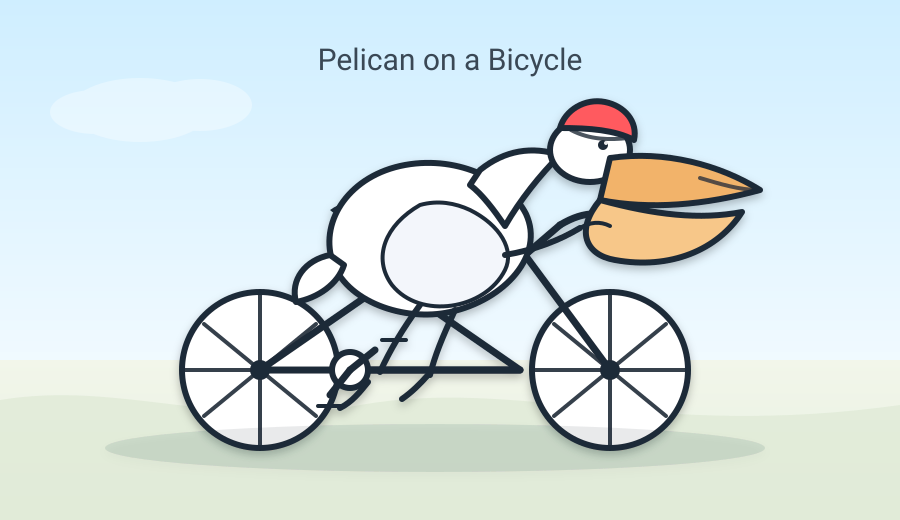

In [40]:
from IPython.display import SVG, display
display(SVG('../assets/bicycle.svg'))

In [41]:
experiment_a_prompt = """ROLE: You are an experienced internist assessing a complex patient case.

CASE: 58-year-old woman presents with:
- 3 weeks of progressive fatigue
- Unexplained weight loss of 4 kg last month
- Low-grade fever (37.8°C) in the evenings
- Night sweats
- Generalized lymphadenopathy
- Laboratory: Hb 10.2, MCV 88, WBC 3.2, PLT 120, ESR 65, CRP 35

TASK: Generate differential diagnoses with probability assessment.

<uncertainty_handling>
- Present diagnoses ranked by probability
- For each diagnosis: State supporting and conflicting findings
- Explicitly state which additional investigations will help distinguish the diagnoses
- Clearly state uncertainty and limitations in the assessment
- DO NOT give absolute conclusions - this is a clinical assessment requiring complete history and examination
</uncertainty_handling>

ANSWER FORMAT:
1. Differential diagnoses (ranked with estimated probability)
2. Critical investigations that should be ordered
3. Red flags requiring immediate action
4. Uncertainty assessment"""

_How do I give this prompt to llm -m gpt-5.2 in a code cell?_

Use subprocess with stdin
```python
import subprocess
result = subprocess.run(
    ["llm", "-m", "gpt-5.2"],
    input=experiment_a_prompt,
    capture_output=True,
    text=True
)
print(result.stdout)
```

1. Differensialdiagnoser (rangert med estimert sannsynlighet)
*(Estimater er grove og basert kun på oppgitte data: B‑symptomer + generalisert lymfadenopati + pancytopenitendens + høy SR/CRP. Reell sannsynlighet kan endre seg betydelig med anamnese/undersøkelse.)*

**1) Malignt lymfom (Hodgkin eller non‑Hodgkin) – ca. 35–45%**
- **Støttende funn:** B‑symptomer (vekttap, nattesvette, feber), generalisert lymfadenopati, inflammatoriske markører (SR 65, CRP 35), cytopenier (Hb lav, LPK 3.2, TPK 120) som kan skyldes benmargsinfiltrasjon eller hypersplenisme.
- **Motstridende/uklart:** Ingen opplysninger om kløe, alkoholindusert lymfeknutesmerte, lokalisasjon/størrelse/konsistens, hepatosplenomegali.
- **Skillerundersøkelser:**  
  - Eksisjonsbiopsi av representativ lymfeknute (hel node) med histologi, immunhistokjemi, flowcytometri.  
  - CT hals/thorax/abdomen/bekken eller PET‑CT for utbredelse.  
  - Blodutstryk, LD, urinsyre, leverprøver.  
  - Benmargsundersøkelse ved cytopenier/for staging.

**2) Akutt/ subakutt hematologisk malignitet (leukemi/MDS) – ca. 20–30%**
- **Støttende funn:** Pancytopeni-tendens (anemi, leukopeni, trombocytopeni), systemiske symptomer, infeksjons-/inflammasjonsmarkører kan være forhøyet, lymfadenopati kan forekomme (særlig ved enkelte leukemier/lymfoproliferative tilstander).
- **Motstridende/uklart:** Hb 10.2 og normocytose uten tydelig blast-bilde (ikke oppgitt), symptomvarighet 3 uker (kan passe, men også til andre årsaker). Lymfadenopati er mer “klassisk” for lymfom enn for MDS.
- **Skillerundersøkelser:**  
  - Full blodstatus med differensial, **blodutstryk** (blaster/dysplasi).  
  - Retikulocytter, LD, haptoglobin, bilirubin (hemolyse?)  
  - Benmargsaspirat/-biopsi med cytogenetikk/flow.  
  - Koagulasjonsprøver (ved mistanke om akutt leukemi).

**3) Disseminert infeksjon (særlig HIV, EBV/CMV, tuberkulose, ev. andre) – ca. 15–25%**
- **Støttende funn:** Feber, nattesvette, vekttap, generalisert lymfadenopati, cytopenier kan ses ved HIV og disseminerte infeksjoner, moderat CRP/SR.
- **Motstridende/uklart:** Feber relativt lavgradig; ingen opplysninger om hoste, eksponering, sår hals, lever/splen-forstørrelse, utslett, risikofaktorer.
- **Skillerundersøkelser:**  
  - HIV Ag/Ab, ev. HIV‑RNA ved tidlig mistanke.  
  - EBV/CMV serologi (tolket med klinikk), parvovirus B19 ved cytopenier.  
  - IGRA/Quantiferon + rtg thorax/CT (TB), sputum/PCR ved symptomer.  
  - Blodkulturer ved feber, ev. mykobakterie-/soppdiagnostikk ved relevant epidemiologi.  

**4) Systemisk autoimmun/inflammatorisk sykdom (f.eks. SLE, Sjögren, RA/Felty, sarkoidose) – ca. 5–10%**
- **Støttende funn:** Cytopenier kan være immunmedierte (SLE), SR ofte høy; lymfadenopati kan forekomme; konstitusjonelle symptomer.
- **Motstridende/uklart:** Mangler typiske organsymptomer (artralgi, utslett, fotosensitivitet, munn-/øyesymptomer, serositt, nyreaffeksjon). CRP er moderat forhøyet (ved SLE kan CRP ofte være relativt lav med mindre infeksjon/serositt).
- **Skillerundersøkelser:**  
  - ANA, anti-dsDNA, ENA, komplement (C3/C4), urinstiks/albumin-kreatinin, SR/CRP trend.  
  - Ferritin, ACE (sarkoidose), Ca, evt. biopsi ved suspekte funn.

**5) Metastatisk solid malignitet med sekundær benmargspåvirkning / paraneoplasi – ca. 5–10%**
- **Støttende funn:** Vekttap, feber/nattesvette kan forekomme; cytopenier kan skyldes benmargsinfiltrasjon; SR høy.
- **Motstridende/uklart:** Generalisert lymfadenopati peker mer mot lymfoproliferativ/infeksiøs årsak enn “vanlig” solid tumor (men ikke umulig).
- **Skillerundersøkelser:**  
  - CT thorax/abdomen/bekken (ofte uansett ved slik presentasjon).  
  - Mammografi/gynekologisk vurdering etter alder/rutiner/symptomer.  
  - Benmarg ved uforklarte cytopenier.

**6) Medikament-/toksisk årsak eller ernæringssvikt med infeksjon samtidig – ca. 2–5%**
- **Støttende funn:** Cytopenier kan være medikamentutløst; feber kan være legemiddelreaksjon.
- **Motstridende/uklart:** Forklarer ikke godt generalisert lymfadenopati + B‑symptomer samlet.
- **Skillerundersøkelser:**  
  - Nøye legemiddel-/naturmiddel-anamnese, alkohol, eksponeringer.  
  - B12/folat, jernstatus, leverprøver, TSH; revurdering etter seponering ved mistanke.

---

2. Kritiske undersøkelser som bør bestilles
**A. “Må ha” tidlig (samme dag/innen få dager)**
- Klinisk: full status med kartlegging av **lymfeknutestasjoner**, størrelse, konsistens, ømhet, hudforandringer; vurder **hepatosplenomegali**.
- Blodprøver:
  - Full blodstatus med differensial + **blodutstryk** (blaster/dysplasi/atypiske lymfocytter)
  - Retikulocytter
  - LD, urinsyre
  - Lever- og nyrestatus, elektrolytter, albumin
  - Ferritin, jern/TIBC, B12/folat
  - Hemolyseprøver ved behov (haptoglobin, bilirubin, DAT)
  - Koagulasjon (INR, APTT, fibrinogen) hvis malignitet/akutt sykdom mistenkes
- Infeksjon:
  - HIV Ag/Ab
  - EBV/CMV (målrettet; tolk med klinikk)
  - Blodkulturer hvis feber/topper
- Bilde:
  - **CT hals/thorax/abdomen/bekken** (eller PET‑CT dersom lymfom sterkt mistenkt og tilgjengelig i pakkeforløp)

**B. Avklarende “nøkkelundersøkelser”**
- **Eksisjonsbiopsi av lymfeknute** (prioriteres høyt ved generalisert lymfadenopati + B‑symptomer)
- Benmargsaspirat/-biopsi (særlig pga cytopenier)
- TB-utredning ved klinikk/risiko: IGRA + thoraxbilde ± mikrobiologi
- Autoimmunitet ved klinisk mistanke: ANA, dsDNA, ENA, C3/C4, urinanalyse (protein/hematuri)

---

3. Røde flagg som krever umiddelbar handling
- **Tegn til sepsis eller klinisk forverring:** stigende feber, hypotensjon, takykardi, påvirket allmenntilstand.
- **Nøytropeni eller alvorlig leukopeni med infeksjonstegn:** (LPK 3.2 er ikke nødvendigvis nøytropeni; ANC må avklares). Feber + nøytropeni → akutt innleggelse og antibiotika.
- **Raskt progredierende cytopenier** eller blødningstendens (TPK fall, petekkier, slimhinneblødning).
- **Mistanke om akutt leukemi:** blaster på utstryk, uttalt slapphet/dyspné, blåmerker, infeksjoner → hastehenvisning hematologi/innleggelse.
- **Kompresjonssymptomer fra lymfeknuter/mediastinal masse:** dyspné, stridor, ansiktshevelse (SVC‑syndrom), dysfagi.
- **Uforklarlig betydelig vekttap og nattlige svetter** med cytopenier → bør håndteres raskt i pakkeforløp kreft/hematologi.

---

4. Usikkerhetsvurdering
- Vurderingen er begrenset av mangel på: lymfeknutenes lokalisasjon/størrelse, hepatosplenomegali, hud/ledd/luftveissymptomer, reise/eksponering, medikamentliste, røyking/alkohol, og differensialtelling (nøytrofile/lymfocytter).
- Cytopeniene kan representere alt fra reaktiv inflammasjon til benmargssvikt/infiltrasjon; uten blodutstryk og benmargsvurdering kan man ikke skille dette sikkert.
- Generalisert lymfadenopati + B‑symptomer gjør malignitet (særlig lymfom) relativt sannsynlig, men flere infeksjoner (særlig HIV/TB) kan gi svært likt bilde. Derfor er **biopsi + bred basisutredning** nødvendig før man konkluderer.

Hvis du kan oppgi: lymfeknutelokalisasjon (hals/axille/lyske), størrelse/ømhet, hepatosplenomegali, differensialtelling/ANC, LD, leverprøver og evt. CT-funn, kan sannsynlighetene justeres mer presist.

---

## 8. Claude Opus 4.5 Prompting Guide for Medicine

Anthropic launched Claude Opus 4.5 as their most advanced model, with special emphasis on *safety*, *nuanced reasoning* and *ethical awareness*. These characteristics make the model particularly well-suited for medical applications.

### 8.1 Introduction to Claude Opus 4.5

Claude Opus 4.5 distinguishes itself from other models with:
- **Constitutional AI**: Built-in ethical framework that guides responses
- **Nuanced reasoning**: Exceptionally good at balancing conflicting considerations
- **Long context**: Supports up to 200K tokens (entire textbooks/medical records)
- **Honest uncertainty**: Trained to acknowledge limitations without excessive caution

For medical applications, this provides:
- Better handling of ethical dilemmas in clinical practice
- More balanced presentation of treatment alternatives
- Stronger protection of patient autonomy in responses
- Natural communication of medical uncertainty

### 8.2 Ethical Considerations and Nuanced Medical Reasoning

Claude is particularly strong on tasks requiring balancing of conflicting considerations. Anthropic's recommendations for medical prompts:

```
<ethical_reasoning>
When assessing medical questions with ethical dimensions:

1. PERSPECTIVES: Present all relevant perspectives
   - Patient autonomy and wishes
   - Medical best practice
   - Family concerns
   - Resource considerations and justice

2. TRADE-OFFS: Explicitly discuss tensions between:
   - Beneficence vs. autonomy
   - Non-maleficence vs. treatment benefit
   - Individual vs. societal considerations

3. HUMILITY: Acknowledge the complexity
   - "This is a genuinely difficult question because..."
   - "Reasonable people can disagree about..."
   - "I can present perspectives, but the decision must be made by..."

4. BOUNDARIES: Be clear about role limitations
   - AI provides information, not decisions
   - Clinical judgment requires human assessment
   - The patient-physician relationship is central
</ethical_reasoning>
```

In [42]:
# Claude Opus 4.5: Prompt for Ethical Medical Reasoning

ethical_prompt_claude = """You are a clinical ethics consultant who helps healthcare personnel with difficult decisions.

<context>
Case: 82-year-old woman with advanced dementia and newly diagnosed cancer.
Family members disagree about treatment intensity.
Patient does not have a valid advance directive.
</context>

<task>
Help the treatment team structure an ethical reflection around treatment choices.
</task>

<format>
Present the analysis in the following structure:

1. FACTUAL BASIS
   - Medical situation
   - Patient's previously expressed wishes (if known)
   - Family members' viewpoints

2. ETHICAL PRINCIPLES AT PLAY
   - Autonomy: How to respect patient's will when capacity is lacking?
   - Beneficence: What is in the patient's best interest?
   - Non-maleficence: Which treatments may cause unnecessary suffering?
   - Justice: Are there resource considerations to evaluate?

3. ACTION ALTERNATIVES
   - Alternative A: [Describe]
   - Alternative B: [Describe]
   - Alternative C: [Describe]

4. PROCESS RECOMMENDATION
   - Which conversations should be conducted?
   - Who should be involved?
   - Time perspective for decision

5. LIMITATIONS
   - What cannot AI contribute in this case?
</format>

<important>
This is support for clinical reflection, not a decision. 
Final assessment must be made by the treating physician in dialogue with family members.
</important>
"""

print("CLAUDE OPUS 4.5: ETHICAL REASONING PROMPT")
print("=" * 60)
print(ethical_prompt_claude)

CLAUDE OPUS 4.5: ETHICAL REASONING PROMPT
You are a clinical ethics consultant who helps healthcare personnel with difficult decisions.

<context>
Case: 82-year-old woman with advanced dementia and newly diagnosed cancer.
Family members disagree about treatment intensity.
Patient does not have a valid advance directive.
</context>

<task>
Help the treatment team structure an ethical reflection around treatment choices.
</task>

<format>
Present the analysis in the following structure:

1. FACTUAL BASIS
   - Medical situation
   - Patient's previously expressed wishes (if known)
   - Family members' viewpoints

2. ETHICAL PRINCIPLES AT PLAY
   - Autonomy: How to respect patient's will when capacity is lacking?
   - Beneficence: What is in the patient's best interest?
   - Non-maleficence: Which treatments may cause unnecessary suffering?
   - Justice: Are there resource considerations to evaluate?

3. ACTION ALTERNATIVES
   - Alternative A: [Describe]
   - Alternative B: [Describe]
   -

### 8.3 Long Context and Document Analysis

Claude Opus 4.5 can handle up to 200K tokens (~150,000 words) in one request. This enables:
- Analysis of complete patient records over several years
- Review of entire research articles with references
- Compilation of information from multiple sources

**Best practices for long context in medicine:**

```
<long_context_medicine>
When analyzing long medical documents:

STRUCTURE:
- Place the most important first (newest notes, main problem)
- Use clear section markers: <journal>, <lab>, <medications>
- Include timestamps for chronological understanding

INSTRUCTIONS:
- Ask for specific references to source documents
- Require citation marking: "According to note from [date]..."
- Ask for summary before detailed analysis

QUALITY ASSURANCE:
- "If information is missing, state this explicitly"
- "For conflicting information, point out the discrepancy"
- "Clearly distinguish between facts from the record and your assessments"
</long_context_medicine>
```

In [43]:
# Claude Opus 4.5: Long Context Medical Record Analysis

long_context_prompt = """You are a medical information assistant who helps doctors with medical record review.

<task>
Analyze the attached patient record and generate a structured summary 
for new treating physician.
</task>

<record>
[Here the entire patient record will be included - up to 150,000 words]
</record>

<output_structure>
## Patient Overview

### Demographic Information
- Date of birth, gender, contact info

### Primary Diagnoses (chronological)
For each diagnosis:
- Diagnosis date and source (e.g., "According to discharge summary 15.03.2022")
- ICD-10 code
- Current status (active/inactive/resolved)

### Active Medication List
Table with: Medication | Dose | Indication | Start | Prescriber

### Important Events (timeline)
- Year 20XX: [Event with source reference]
- ...

### Allergies and Warnings
With source for each entry

### Open Issues
What requires follow-up?

### Information Gaps
What is missing in the record that the new doctor should clarify?
</output_structure>

<rules>
1. ALWAYS refer to source note with date
2. For conflicting info: Present both with dates
3. Mark uncertainty with [?]
4. Distinguish between documented facts and your interpretations
5. Flag critical information with ⚠️
</rules>
"""

print("CLAUDE OPUS 4.5: LONG CONTEXT MEDICAL RECORD ANALYSIS")
print("=" * 60)
print(long_context_prompt)

CLAUDE OPUS 4.5: LONG CONTEXT MEDICAL RECORD ANALYSIS
You are a medical information assistant who helps doctors with medical record review.

<task>
Analyze the attached patient record and generate a structured summary 
for new treating physician.
</task>

<record>
[Here the entire patient record will be included - up to 150,000 words]
</record>

<output_structure>
## Patient Overview

### Demographic Information
- Date of birth, gender, contact info

### Primary Diagnoses (chronological)
For each diagnosis:
- Diagnosis date and source (e.g., "According to discharge summary 15.03.2022")
- ICD-10 code
- Current status (active/inactive/resolved)

### Active Medication List
Table with: Medication | Dose | Indication | Start | Prescriber

### Important Events (timeline)
- Year 20XX: [Event with source reference]
- ...

### Allergies and Warnings
With source for each entry

### Open Issues
What requires follow-up?

### Information Gaps
What is missing in the record that the new doctor should

### 8.4 Honest Uncertainty and Calibrated Confidence

A key strength of Claude is the ability to express uncertainty in a *calibrated* way - neither excessively cautious nor overconfident. Anthropic recommends:

```
<calibrated_uncertainty>
Express uncertainty in a nuanced way:

HIGHER CONFIDENCE (use when evidence is strong):
- "Based on established medical consensus..."
- "This is well documented in the literature..."
- "Current guidelines are clear that..."

MODERATE CONFIDENCE (use with good, but not definitive evidence):
- "Available evidence suggests..."
- "Most studies indicate..."
- "This is likely the case, although..."

LOWER CONFIDENCE (use with limited or conflicting evidence):
- "There is uncertainty around this because..."
- "Different sources provide conflicting information..."
- "My assessment is limited by..."

ACKNOWLEDGE KNOWLEDGE GAPS:
- "I do not have sufficient information to assess..."
- "This question requires clinical examination that AI cannot perform"
- "Recent research may have changed this - verify against updated sources"
</calibrated_uncertainty>
```

**Medical application**: This is particularly important for:
- Rare diagnoses with limited evidence base
- New treatments without long-term data
- Individual variations that affect treatment response

### 8.5 Summary: Claude Opus 4.5 in Medical Context

**Key Points from Anthropic Best Practices Adapted for Medicine:**

| Topic | Claude Strength | Prompt Strategy |
|------|----------------|-----------------|
| **Ethics** | Constitutional AI | Use `<ethical_reasoning>` structure for complex trade-offs |
| **Long context** | 200K tokens | Structure with section markers, require source references |
| **Uncertainty** | Calibrated confidence | Ask for graded confidence levels in assessments |
| **Patient-centered** | Autonomy focus | Include patient perspective explicitly in prompts |

**When to Choose Claude for Medical Tasks?**
- ✅ Ethical dilemmas and value considerations
- ✅ Analysis of long documents (medical records, research articles)
- ✅ Patient communication with empathetic tone
- ✅ Tasks requiring nuanced language and humility

**Limitations to Be Aware Of:**
- Can be *too* cautious on certain tasks
- Less tool integration than GPT-5.2
- Limited real-time information (no built-in web search)

---

*Source: [Anthropic Claude Documentation](https://docs.anthropic.com) and [Claude Prompt Engineering Guide](https://docs.anthropic.com/claude/docs/prompt-engineering)*

---

## 9. Gemini 3 Prompting Guide for Medicine

Google DeepMind's Gemini 3 represents a new generation of multimodal models with special strengths in *scientific reasoning*, *multimodal analysis* and *real-time information search*. For medical applications, this provides unique opportunities.

### 9.1 Introduction to Gemini 3

Gemini 3 excels at:
- **Multimodal understanding**: Analyzes text, images, video and audio simultaneously
- **Scientific reasoning**: Trained on extensive scientific literature
- **Google Search integration**: Real-time access to updated information
- **Long context windows**: Up to 1M tokens in extended versions

For medical applications, this means:
- Direct analysis of X-ray images, CT scans, skin lesions
- Combined analysis of ECG images and symptom descriptions
- Updated information about medications, guidelines and research
- Video processing (e.g., gait analysis, tremor assessment)

### 9.2 Multimodal Medical Analysis

Gemini's multimodal capacity makes it possible to analyze medical images together with clinical information. Google recommends the following prompt pattern:

```
<multimodal_medicine>
When analyzing medical images:

CONTEXT FIRST:
- Provide clinical information BEFORE the image
- Specify image type (X-ray, CT, dermoscopy, etc.)
- Provide technical parameters if available

STRUCTURED ANALYSIS:
- Ask for systematic review (e.g., ABCDE for skin lesions)
- Require description before interpretation
- Distinguish between observations and assessments

LIMITATIONS:
- "This is a guiding analysis, not a formal radiological interpretation"
- "Final diagnosis requires examination by qualified specialist"
- Ask for confidence level for findings

QUALITY REQUIREMENTS:
- "Describe what you observe in the image"
- "Which differential diagnoses should be considered?"
- "Which additional investigations would be useful?"
</multimodal_medicine>
```

> ⚠️ **Important**: Multimodal medical analysis is under active development and regulation. Use only as decision support, never as the sole diagnostic tool.

In [44]:
# Gemini 3: Multimodal Medical Analysis Prompt

multimodal_prompt_gemini = """You are a medical image analysis assistant who supports clinicians.

<clinical_context>
Patient: 67-year-old man
Chief complaint: Cough for 6 weeks, weight loss 5 kg
Smoking history: 40 pack-years
Image type: Chest X-ray, frontal view
</clinical_context>

<image>
[IMAGE ATTACHED HERE]
</image>

<analysis_instructions>
Perform a systematic analysis of the chest X-ray:

1. TECHNICAL QUALITY
   - Image position and exposure
   - Is the image adequate for assessment?

2. SYSTEMATIC REVIEW
   - Soft tissues and skeleton
   - Mediastinum (width, contours)
   - Hilar regions (symmetry, size)
   - Lung parenchyma (bilateral comparison)
   - Pleura and costophrenic angles
   - Heart contour and size

3. FINDINGS
   For each finding, state:
   - Description (what is observed objectively)
   - Location
   - Possible significance
   - Confidence level (high/moderate/low)

4. CONCLUSION
   - Summary of main findings
   - Differential diagnoses to consider
   - Recommended follow-up/additional investigations

5. LIMITATIONS
   - What cannot be assessed from this image?
</analysis_instructions>

<important>
⚠️ This is guiding analysis for decision support.
Formal radiological interpretation must be performed by a radiologist.
</important>
"""

print("GEMINI 3: MULTIMODAL MEDICAL ANALYSIS")
print("=" * 60)
print(multimodal_prompt_gemini)

GEMINI 3: MULTIMODAL MEDICAL ANALYSIS
You are a medical image analysis assistant who supports clinicians.

<clinical_context>
Patient: 67-year-old man
Chief complaint: Cough for 6 weeks, weight loss 5 kg
Smoking history: 40 pack-years
Image type: Chest X-ray, frontal view
</clinical_context>

<image>
[IMAGE ATTACHED HERE]
</image>

<analysis_instructions>
Perform a systematic analysis of the chest X-ray:

1. TECHNICAL QUALITY
   - Image position and exposure
   - Is the image adequate for assessment?

2. SYSTEMATIC REVIEW
   - Soft tissues and skeleton
   - Mediastinum (width, contours)
   - Hilar regions (symmetry, size)
   - Lung parenchyma (bilateral comparison)
   - Pleura and costophrenic angles
   - Heart contour and size

3. FINDINGS
   For each finding, state:
   - Description (what is observed objectively)
   - Location
   - Possible significance
   - Confidence level (high/moderate/low)

4. CONCLUSION
   - Summary of main findings
   - Differential diagnoses to consider
   - 

### 9.3 Real-Time Search and Updated Medical Knowledge

A major advantage of Gemini is integration with Google Search, which provides access to:
- Latest research publications
- Updated medication information
- Current guidelines and recommendations
- Latest news about disease outbreaks and public health

**Best practices for medical real-time search:**

```
<medical_realtime_search>
When searching for updated medical information:

SOURCE QUALITY:
- Prioritize: PubMed, Cochrane, UpToDate, national guidelines
- Avoid: Non-peer-reviewed sources, patient forums, commercial sites
- Verify: Check publication date and update status

SEARCH STRATEGY:
- Use MeSH terms and medical terminology
- Specify population, intervention, comparator, outcome (PICO)
- State desired evidence level and study design

REPORTING:
- Always provide source with URL and publication date
- Mark if information is recently updated
- Indicate if there are conflicting findings across sources

TIME RELEVANCE:
- For medications: Check against latest formulary/SPC
- For guidelines: Verify that current version is used
- For research: Mark pre-prints and non-peer-reviewed material
</medical_realtime_search>
```

In [45]:
# Gemini 3: Medical Real-Time Search Prompt

realtime_search_prompt = """You are a medical research assistant with access to real-time web search.

<clinical_question>
What is the latest evidence for use of GLP-1 agonists 
in non-alcoholic fatty liver disease (NAFLD/NASH)?
</clinical_question>

<search_structure>
Perform a systematic literature search with the following approach:

1. PRIMARY SEARCH
   - Search PubMed/MEDLINE for systematic reviews and RCTs from the last 2 years
   - Check Cochrane Database for relevant reviews
   - Find current guidelines from EASL, AASLD

2. QUALITY ASSESSMENT
   For each main source, assess:
   - Study design and quality
   - Population size
   - Relevance for clinical practice
   - Publication date and whether it is peer-reviewed

3. SYNTHESIS
   Present findings in the following format:
   
   | Study | Design | N | Main Findings | Evidence Strength |
   |-------|--------|---|---------------|------------------|
   
4. CLINICAL IMPLICATION
   - What do current guidelines say?
   - Is there consensus or ongoing debate?
   - Which patient groups may benefit?
   
5. KNOWLEDGE GAPS
   - Which questions are not sufficiently answered?
   - Ongoing studies to follow?
</search_structure>

<source_requirements>
- ALWAYS provide full source reference with URL
- Mark publication date for each source
- Indicate if anything is preprint or non-peer-reviewed
- Provide date for the search
</source_requirements>
"""

print("GEMINI 3: MEDICAL REAL-TIME SEARCH")
print("=" * 60)
print(realtime_search_prompt)

GEMINI 3: MEDICAL REAL-TIME SEARCH
You are a medical research assistant with access to real-time web search.

<clinical_question>
What is the latest evidence for use of GLP-1 agonists 
in non-alcoholic fatty liver disease (NAFLD/NASH)?
</clinical_question>

<search_structure>
Perform a systematic literature search with the following approach:

1. PRIMARY SEARCH
   - Search PubMed/MEDLINE for systematic reviews and RCTs from the last 2 years
   - Check Cochrane Database for relevant reviews
   - Find current guidelines from EASL, AASLD

2. QUALITY ASSESSMENT
   For each main source, assess:
   - Study design and quality
   - Population size
   - Relevance for clinical practice
   - Publication date and whether it is peer-reviewed

3. SYNTHESIS
   Present findings in the following format:
   
   | Study | Design | N | Main Findings | Evidence Strength |
   |-------|--------|---|---------------|------------------|
   
4. CLINICAL IMPLICATION
   - What do current guidelines say?
   - Is th

### 9.4 Scientific Reasoning and Medical Calculations

Gemini 3 is trained on extensive scientific literature and shows strong abilities in:
- Complex medical calculations
- Pharmacokinetic assessments
- Statistical interpretation of research results
- Physiological reasoning

```
<scientific_reasoning>
For medical calculations and scientific analysis:

CALCULATIONS:
- Always show intermediate calculations step by step
- State formulas used with reference
- Double-check units and order of magnitude
- Provide normal values for comparison

PHARMACOKINETICS:
- Take into account renal function (eGFR/CrCl)
- Assess drug interactions
- Calculate half-life and accumulation
- Assess need for dose adjustment

STATISTICS:
- Explain clinical vs. statistical significance
- Calculate NNT/NNH when relevant
- Assess confidence intervals, not just p-values
- Discuss generalizability

PHYSIOLOGY:
- Use mechanistic explanations
- Show the relationship between systems
- Explain compensation mechanisms
</scientific_reasoning>
```

### 9.5 Summary: Gemini 3 in Medical Context

**Key Points from Google Best Practices Adapted for Medicine:**

| Topic | Gemini Strength | Prompt Strategy |
|-------|----------------|-----------------|
| **Multimodal** | Image + text | Provide clinical context before image, require systematic analysis |
| **Real-time search** | Google Search | Specify source quality, require URL and dates |
| **Science** | Trained on research | Ask for stepwise reasoning, verify calculations |
| **Long context** | Up to 1M tokens | Structure input, use clear section markers |

**When to Choose Gemini for Medical Tasks?**
- ✅ Multimodal analysis (images + clinical info)
- ✅ Updated information via web search
- ✅ Complex calculations and pharmacokinetics
- ✅ Scientific literature search

**Limitations to Be Aware Of:**
- Image analysis is *not* validated for clinical diagnosis
- Real-time search may include non-quality-assured sources
- Less focus on ethical considerations than Claude
- Availability may vary by region

---

*Source: [Google AI for Developers](https://ai.google.dev/docs) and [Gemini API Documentation](https://ai.google.dev/gemini-api/docs)*

---

## Comparison: Model Selection for Medical Tasks

### Decision Matrix

| Task Type | Recommended Model | Rationale |
|-----------|-------------------|-----------|
| **Structured extraction** (JSON, schema) | GPT-5.2 | Good instruction following |
| **Ethical dilemmas** | Claude Opus 4.5 | Constitutional AI, nuanced reasoning |
| **Image analysis** (X-ray, dermatology) | Gemini 3 | Multimodal from the ground up |
| **Long medical record analysis** | Claude Opus 4.5 | 200K tokens, good source referencing |
| **Updated research** | Gemini 3 | Integrated real-time search |
| **Tool integration** | GPT-5.2 | Good API for functions/tools |
| **Patient communication** | Claude Opus 4.5 | Empathetic tone, patient-centered |
| **Calculations** | Gemini 3 | Strong on science and mathematics |

### Practical Recommendation

For critical medical tasks, it is recommended:
1. **Test on multiple models** - Compare output
2. **Choose based on task** - No model is best at everything
3. **Always verify** - AI is decision support, not decision maker
4. **Document model choice** - Important for reproducibility

---

## Summary

### Best Practices for Medical Prompts

**DO:**
- Specify role and context
- Provide examples (few-shot) for consistency
- Use stepwise reasoning (CoT) for complex assessments
- Always include safety instructions
- Ask for structured output when relevant
- Use GPT-5.2 patterns for uncertainty handling and self-check (see section 7)
- Test prompts on multiple models for critical tasks

**DON'T:**
- Blindly trust AI for critical decisions
- Ask for specific medication dosages
- Forget to include disclaimers
- Ignore uncertainty in AI responses
- Use AI output without clinical validation

### Reflection Tasks

1. Design a prompt to generate patient information about a condition of your choice
2. How would you modify the triage prompt to handle children specifically?
3. Which safety considerations are most important in your future practice?
4. **New**: Conduct experiment A, B or C from section 7 and compare output from at least two models (GPT-5.2, Claude Opus 4.5, Gemini 3)

---

*Next notebook: [05 - Explainable AI (XAI)](05-xai-explainable-ai.ipynb)*